# Method: DeepLabV3 Wheat Segmentation

This method was adapted from the **CIFAR-10 demo shown in the lecture, Week 7 Deep Learning Part 1-2 on April 2**. We kept the same general PyTorch workflow from that example, like loading the data, defining the network, choosing a loss function and optimizer, training the model, and then testing the results. 

The main difference is that our project is a **segmentation** task instead of a classification task, so instead of predicting one label for the whole image, the model predicts a mask showing wheat and background.



## 1. Load and normalize the wheat dataset

Expected folder structure:

- project/
    - data/
        - train/
        - validation/
        - test/



In [108]:
# if you are running in a notebook
%matplotlib inline


In [109]:
import time
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# so we can use pretrained weights
from torchvision.models.segmentation import (
    deeplabv3_resnet50,
    DeepLabV3_ResNet50_Weights
)


In [110]:
DATA_DIR = Path("data")
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "validation"
TEST_DIR = DATA_DIR / "test"

print("train exists     :", TRAIN_DIR.exists())
print("validation exists:", VAL_DIR.exists())
print("test exists      :", TEST_DIR.exists())


train exists     : True
validation exists: True
test exists      : True


In [111]:
class WheatSegmentationDataset(Dataset):
    def __init__(self, split_dir, image_size=(256, 256)):
        self.split_dir = Path(split_dir)
        self.image_size = image_size
        self.image_paths = sorted(
            [p for p in self.split_dir.glob("*.png") if not p.name.endswith("_mask.png")]
        )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        mask_path = image_path.with_name(image_path.stem + "_mask.png")

        image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, self.image_size, interpolation=cv2.INTER_LINEAR)
        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))

        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, self.image_size, interpolation=cv2.INTER_NEAREST)
        mask = (mask > 127).astype(np.float32)
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)


In [112]:
trainset = WheatSegmentationDataset(TRAIN_DIR, image_size=(256, 256))
valset = WheatSegmentationDataset(VAL_DIR, image_size=(256, 256))
testset = WheatSegmentationDataset(TEST_DIR, image_size=(256, 256))

trainloader = DataLoader(trainset, batch_size=4, shuffle=True, num_workers=0)
valloader = DataLoader(valset, batch_size=4, shuffle=False, num_workers=0)
testloader = DataLoader(testset, batch_size=4, shuffle=False, num_workers=0)

print("training images  :", len(trainset))
print("validation images:", len(valset))
print("test images      :", len(testset))


training images  : 142
validation images: 24
test images      : 24


Show some training images and masks, to check if its doing what we want it to.


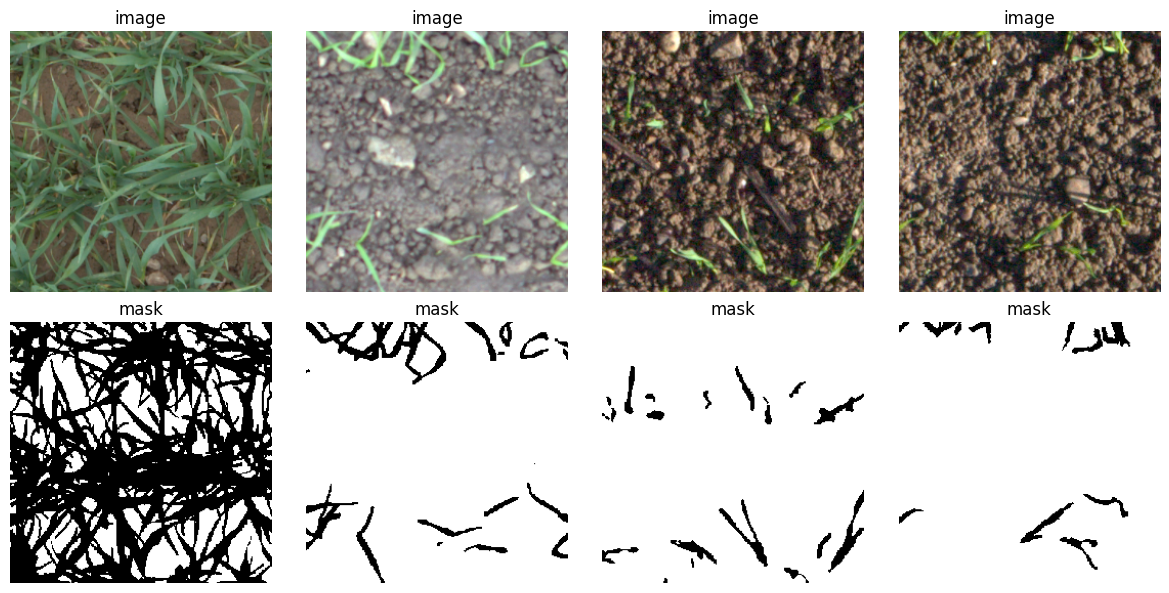

In [113]:
images, masks = next(iter(trainloader))

fig, ax = plt.subplots(2, 4, figsize=(12, 6))

for i in range(4):
    img = images[i].numpy().transpose(1, 2, 0)
    msk = masks[i, 0].numpy()

    ax[0, i].imshow(img)
    ax[0, i].set_title("image")
    ax[0, i].axis("off")

    ax[1, i].imshow(msk, cmap="gray")
    ax[1, i].set_title("mask")
    ax[1, i].axis("off")

plt.tight_layout()
plt.show()


## 2. Define the Neural Network

For this method, we are using **DeepLabV3** as the main model. Because our task only has **two classes** (wheat and background) we changed the last part of the network so it gives us **one output channel** instead of multiple classes. This lets the model produce a binary segmentation mask for each image.

In [114]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("using device:", device)


using device: mps


In [115]:
# using ResNet50 backbone visual features (instead of none)

net = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.DEFAULT)

in_channels = net.classifier[4].in_channels
net.classifier[4] = nn.Conv2d(in_channels, 1, kernel_size=1)

if net.aux_classifier is not None:
    aux_in_channels = net.aux_classifier[4].in_channels
    net.aux_classifier[4] = nn.Conv2d(aux_in_channels, 1, kernel_size=1)

net = net.to(device)
print(net.classifier)


DeepLabHead(
  (0): ASPP(
    (convs): ModuleList(
      (0): Sequential(
        (0): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (1): ASPPConv(
        (0): Conv2d(2048, 256, kernel_size=(3, 3), stride=(1, 1), padding=(12, 12), dilation=(12, 12), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (2): ASPPConv(
        (0): Conv2d(2048, 256, kernel_size=(3, 3), stride=(1, 1), padding=(24, 24), dilation=(24, 24), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
      )
      (3): ASPPConv(
        (0): Conv2d(2048, 256, kernel_size=(3, 3), stride=(1, 1), padding=(36, 36), dilation=(36, 36), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_

In [116]:
for param in net.backbone.parameters():
    param.requires_grad = False

print("backbone frozen")

backbone frozen


In [117]:
bce_loss = nn.BCEWithLogitsLoss()

def dice_loss_fn(logits, targets, smooth=1e-6):
    probs = torch.sigmoid(logits)
    
    probs = probs.contiguous().view(-1)
    targets = targets.contiguous().view(-1)
    
    intersection = (probs * targets).sum()
    dice = (2.0 * intersection + smooth) / (probs.sum() + targets.sum() + smooth)
    
    return 1.0 - dice

def combined_loss(logits, targets):
    bce = bce_loss(logits, targets)
    dice = dice_loss_fn(logits, targets)
    return bce + dice


In [118]:
bce_loss = nn.BCEWithLogitsLoss()

def tversky_loss_fn(logits, targets, alpha=0.3, beta=0.7, smooth=1e-6):
    probs = torch.sigmoid(logits)

    probs = probs.contiguous().view(-1)
    targets = targets.contiguous().view(-1)

    tp = (probs * targets).sum()
    fp = (probs * (1 - targets)).sum()
    fn = ((1 - probs) * targets).sum()

    tversky = (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)
    return 1.0 - tversky

# alpha=0.5, beta=0.5 is closer to Dice
# alpha=0.3, beta=0.7 penalises false negatives more helping recall
# alpha=0.7, beta=0.3 penalises false positives more helping precision

def combined_tversky_loss(logits, targets):
    bce = bce_loss(logits, targets)
    tversky = tversky_loss_fn(logits, targets, alpha=0.6, beta=0.4)
    return bce + tversky

## 3. Define a loss function and optimizer

**BCEWithLogitsLoss** is used for binary segmentation and **Adam** is used for optimization.


In [ ]:

# criterion = nn.BCEWithLogitsLoss()

# fine_tune_run_1
# current best fine-tuned base model
# optimizer = torch.optim.Adam(
#     filter(lambda p: p.requires_grad, net.parameters()),
#     lr=1e-3
# )

# lower learning rates for fine tuning
# fine_tune_run_2
# optimizer = torch.optim.Adam(
#     filter(lambda p: p.requires_grad, net.parameters()),
#     lr=1e-5
# )

# fine_tune_run_3
# optimizer = torch.optim.Adam(
#     filter(lambda p: p.requires_grad, net.parameters()),
#     lr=5e-5
# )

# # fine_tune_run_4 CURRENT BEST RUN
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, net.parameters()),
    lr=2e-5
)

# # fine_tune_run_5 - BCE and Dice
# criterion = combined_loss
# optimizer = torch.optim.Adam(
#     filter(lambda p: p.requires_grad, net.parameters()),
#     lr=1e-3
# )

# # fine_tune_run_6 to 8 - BCE and Dice combined tversky loss
# criterion = combined_tversky_loss
# optimizer = torch.optim.Adam(
#     filter(lambda p: p.requires_grad, net.parameters()),
#     lr=1e-3
# )

## 4. Helper Functions

While the model is training, we will keep checking how well it is doing using the **validation set**. The main results we want to watch are:

- **precision**  
- **recall**  
- **F1-score**  
- **IoU**

These help us see whether the model is improving as it trains, without using the test set too early.

In [120]:
def compute_metrics_from_logits(logits, masks, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(-1).cpu().numpy()
    masks = masks.view(-1).cpu().numpy()

    tp = np.sum((preds == 1) & (masks == 1))
    fp = np.sum((preds == 1) & (masks == 0))
    fn = np.sum((preds == 0) & (masks == 1))

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)

    return precision, recall, f1, iou


In [121]:
def train_one_epoch(net, loader, criterion, optimizer, device):
    net.train()
    running_loss = 0.0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = net(images)["out"]
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)


def evaluate(net, loader, criterion, device):
    net.eval()
    running_loss = 0.0
    precisions, recalls, f1s, ious = [], [], [], []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = net(images)["out"]
            loss = criterion(outputs, masks)

            p, r, f1, iou = compute_metrics_from_logits(outputs, masks)

            running_loss += loss.item()
            precisions.append(p)
            recalls.append(r)
            f1s.append(f1)
            ious.append(iou)

    return {
        "loss": running_loss / len(loader),
        "precision": float(np.mean(precisions)),
        "recall": float(np.mean(recalls)),
        "f1": float(np.mean(f1s)),
        "iou": float(np.mean(ious)),
    }


## 5. Train in stages

We will train to:
- 5 total epochs
- 10 total epochs
- 20 total epochs

and check the **validation** results after each stage.


In [122]:
history = []
current_epoch = 0
total_training_time = 0.0


In [123]:
def train_until(target_epoch, net, trainloader, valloader, criterion, optimizer, device, history, current_epoch):
    stage_start = time.time()

    while current_epoch < target_epoch:
        current_epoch += 1

        train_loss = train_one_epoch(net, trainloader, criterion, optimizer, device)
        val_metrics = evaluate(net, valloader, criterion, device)

        row = {
            "epoch": current_epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_iou": val_metrics["iou"],
        }
        history.append(row)

        print(
            f"epoch {current_epoch} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_precision={val_metrics['precision']:.4f} | "
            f"val_recall={val_metrics['recall']:.4f} | "
            f"val_f1={val_metrics['f1']:.4f} | "
            f"val_iou={val_metrics['iou']:.4f}"
        )

    stage_time = time.time() - stage_start
    return current_epoch, stage_time


### Stage 1: train to 10 total epochs


In [124]:
current_epoch, stage_time = train_until(
    target_epoch=10,
    net=net,
    trainloader=trainloader,
    valloader=valloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    history=history,
    current_epoch=current_epoch,
)
total_training_time += stage_time
print(f"stage finished in {stage_time:.2f} seconds")


epoch 1 | train_loss=0.6701 | val_loss=0.6442 | val_precision=0.8439 | val_recall=0.7775 | val_f1=0.8069 | val_iou=0.6997
epoch 2 | train_loss=0.5132 | val_loss=0.6190 | val_precision=0.8177 | val_recall=0.8604 | val_f1=0.8377 | val_iou=0.7380
epoch 3 | train_loss=0.5085 | val_loss=0.6290 | val_precision=0.8828 | val_recall=0.7584 | val_f1=0.8069 | val_iou=0.6995
epoch 4 | train_loss=0.4900 | val_loss=0.6171 | val_precision=0.8393 | val_recall=0.8209 | val_f1=0.8256 | val_iou=0.7242
epoch 5 | train_loss=0.4685 | val_loss=0.6084 | val_precision=0.8467 | val_recall=0.8282 | val_f1=0.8345 | val_iou=0.7330
epoch 6 | train_loss=0.4733 | val_loss=0.6117 | val_precision=0.8420 | val_recall=0.8370 | val_f1=0.8378 | val_iou=0.7373
epoch 7 | train_loss=0.4665 | val_loss=0.6642 | val_precision=0.8085 | val_recall=0.8752 | val_f1=0.8386 | val_iou=0.7389
epoch 8 | train_loss=0.4582 | val_loss=0.6015 | val_precision=0.8276 | val_recall=0.8699 | val_f1=0.8473 | val_iou=0.7497
epoch 9 | train_loss=0.4

In [125]:
# added so model can adapt to dataset.

for param in net.backbone.parameters():
    param.requires_grad = True

print("backbone unfrozen")

backbone unfrozen


In [126]:
optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)
print("optimizer reset for full fine-tuning")

optimizer reset for full fine-tuning


### Stage 2: continue training to 20 total epochs


In [127]:
current_epoch, stage_time = train_until(
    target_epoch=20,
    net=net,
    trainloader=trainloader,
    valloader=valloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    history=history,
    current_epoch=current_epoch,
)
total_training_time += stage_time
print(f"stage finished in {stage_time:.2f} seconds")


epoch 11 | train_loss=0.4464 | val_loss=0.5229 | val_precision=0.8255 | val_recall=0.9392 | val_f1=0.8774 | val_iou=0.7899
epoch 12 | train_loss=0.3764 | val_loss=0.4341 | val_precision=0.9047 | val_recall=0.8841 | val_f1=0.8927 | val_iou=0.8134
epoch 13 | train_loss=0.3644 | val_loss=0.4367 | val_precision=0.8831 | val_recall=0.9096 | val_f1=0.8954 | val_iou=0.8168
epoch 14 | train_loss=0.3311 | val_loss=0.3977 | val_precision=0.9185 | val_recall=0.8840 | val_f1=0.8996 | val_iou=0.8241
epoch 15 | train_loss=0.3211 | val_loss=0.3894 | val_precision=0.9180 | val_recall=0.8869 | val_f1=0.9009 | val_iou=0.8260
epoch 16 | train_loss=0.3155 | val_loss=0.3993 | val_precision=0.9049 | val_recall=0.9000 | val_f1=0.9013 | val_iou=0.8266
epoch 17 | train_loss=0.3166 | val_loss=0.3832 | val_precision=0.9219 | val_recall=0.8842 | val_f1=0.9016 | val_iou=0.8273
epoch 18 | train_loss=0.2957 | val_loss=0.3885 | val_precision=0.9176 | val_recall=0.8845 | val_f1=0.8995 | val_iou=0.8241
epoch 19 | train

### Stage 3: continue training to 30 total epochs


In [128]:
current_epoch, stage_time = train_until(
    target_epoch=30,
    net=net,
    trainloader=trainloader,
    valloader=valloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    history=history,
    current_epoch=current_epoch,
)
total_training_time += stage_time
print(f"stage finished in {stage_time:.2f} seconds")
print(f"total training time so far: {total_training_time:.2f} seconds")


epoch 21 | train_loss=0.2772 | val_loss=0.3803 | val_precision=0.9061 | val_recall=0.9074 | val_f1=0.9065 | val_iou=0.8344
epoch 22 | train_loss=0.2796 | val_loss=0.3726 | val_precision=0.9183 | val_recall=0.8937 | val_f1=0.9053 | val_iou=0.8326
epoch 23 | train_loss=0.2742 | val_loss=0.3740 | val_precision=0.9087 | val_recall=0.9066 | val_f1=0.9075 | val_iou=0.8359
epoch 24 | train_loss=0.2826 | val_loss=0.3942 | val_precision=0.8924 | val_recall=0.9243 | val_f1=0.9079 | val_iou=0.8363
epoch 25 | train_loss=0.2817 | val_loss=0.3861 | val_precision=0.9032 | val_recall=0.9061 | val_f1=0.9043 | val_iou=0.8313
epoch 26 | train_loss=0.2668 | val_loss=0.3701 | val_precision=0.9121 | val_recall=0.9026 | val_f1=0.9070 | val_iou=0.8354
epoch 27 | train_loss=0.2616 | val_loss=0.3685 | val_precision=0.9125 | val_recall=0.9049 | val_f1=0.9084 | val_iou=0.8376
epoch 28 | train_loss=0.2566 | val_loss=0.3715 | val_precision=0.9116 | val_recall=0.9036 | val_f1=0.9074 | val_iou=0.8359
epoch 29 | train

## another 20 


In [129]:
current_epoch, stage_time = train_until(
    target_epoch=40,
    net=net,
    trainloader=trainloader,
    valloader=valloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    history=history,
    current_epoch=current_epoch,
)
total_training_time += stage_time
print(f"stage finished in {stage_time:.2f} seconds")
print(f"total training time so far: {total_training_time:.2f} seconds")

epoch 31 | train_loss=0.2449 | val_loss=0.3662 | val_precision=0.9207 | val_recall=0.8934 | val_f1=0.9062 | val_iou=0.8343
epoch 32 | train_loss=0.2404 | val_loss=0.3685 | val_precision=0.9148 | val_recall=0.9016 | val_f1=0.9078 | val_iou=0.8367
epoch 33 | train_loss=0.2518 | val_loss=0.3742 | val_precision=0.9060 | val_recall=0.9124 | val_f1=0.9091 | val_iou=0.8385
epoch 34 | train_loss=0.2475 | val_loss=0.3671 | val_precision=0.9248 | val_recall=0.8890 | val_f1=0.9058 | val_iou=0.8336
epoch 35 | train_loss=0.2492 | val_loss=0.3744 | val_precision=0.9040 | val_recall=0.9162 | val_f1=0.9099 | val_iou=0.8397
epoch 36 | train_loss=0.2364 | val_loss=0.3658 | val_precision=0.9262 | val_recall=0.8878 | val_f1=0.9055 | val_iou=0.8334
epoch 37 | train_loss=0.2351 | val_loss=0.3653 | val_precision=0.9171 | val_recall=0.9002 | val_f1=0.9081 | val_iou=0.8371
epoch 38 | train_loss=0.2319 | val_loss=0.3630 | val_precision=0.9236 | val_recall=0.8921 | val_f1=0.9071 | val_iou=0.8354
epoch 39 | train

In [130]:
current_epoch, stage_time = train_until(
    target_epoch=50,
    net=net,
    trainloader=trainloader,
    valloader=valloader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    history=history,
    current_epoch=current_epoch,
)
total_training_time += stage_time
print(f"stage finished in {stage_time:.2f} seconds")
print(f"total training time so far: {total_training_time:.2f} seconds")

epoch 41 | train_loss=0.2318 | val_loss=0.3635 | val_precision=0.9171 | val_recall=0.9019 | val_f1=0.9092 | val_iou=0.8387
epoch 42 | train_loss=0.2250 | val_loss=0.3623 | val_precision=0.9173 | val_recall=0.9023 | val_f1=0.9094 | val_iou=0.8392
epoch 43 | train_loss=0.2259 | val_loss=0.3600 | val_precision=0.9203 | val_recall=0.8996 | val_f1=0.9095 | val_iou=0.8393
epoch 44 | train_loss=0.2250 | val_loss=0.3632 | val_precision=0.9245 | val_recall=0.8921 | val_f1=0.9072 | val_iou=0.8358
epoch 45 | train_loss=0.2275 | val_loss=0.3631 | val_precision=0.9225 | val_recall=0.8951 | val_f1=0.9080 | val_iou=0.8371
epoch 46 | train_loss=0.2229 | val_loss=0.3660 | val_precision=0.9156 | val_recall=0.9038 | val_f1=0.9094 | val_iou=0.8389
epoch 47 | train_loss=0.2199 | val_loss=0.3650 | val_precision=0.9140 | val_recall=0.9070 | val_f1=0.9103 | val_iou=0.8404
epoch 48 | train_loss=0.2239 | val_loss=0.3666 | val_precision=0.9265 | val_recall=0.8878 | val_f1=0.9060 | val_iou=0.8339
epoch 49 | train

## Plot validation improvement


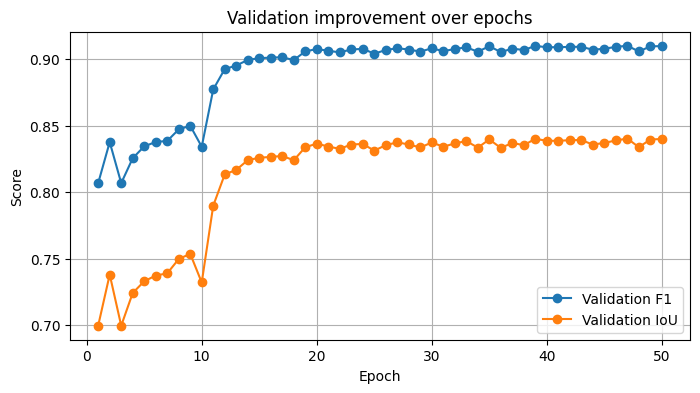

In [131]:
epochs = [row["epoch"] for row in history]
val_f1 = [row["val_f1"] for row in history]
val_iou = [row["val_iou"] for row in history]

plt.figure(figsize=(8, 4))
plt.plot(epochs, val_f1, marker="o", label="Validation F1")
plt.plot(epochs, val_iou, marker="o", label="Validation IoU")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation improvement over epochs")
plt.legend()
plt.grid(True)
plt.show()


## 6. Final test evaluation



In [132]:
test_metrics = evaluate(net, testloader, criterion, device)

print("final test summary")
for k, v in test_metrics.items():
    print(f"{k:>10}: {v:.4f}")


final test summary
      loss: 0.3786
 precision: 0.9215
    recall: 0.9065
        f1: 0.9136
       iou: 0.8419


## Visualise some final test predictions


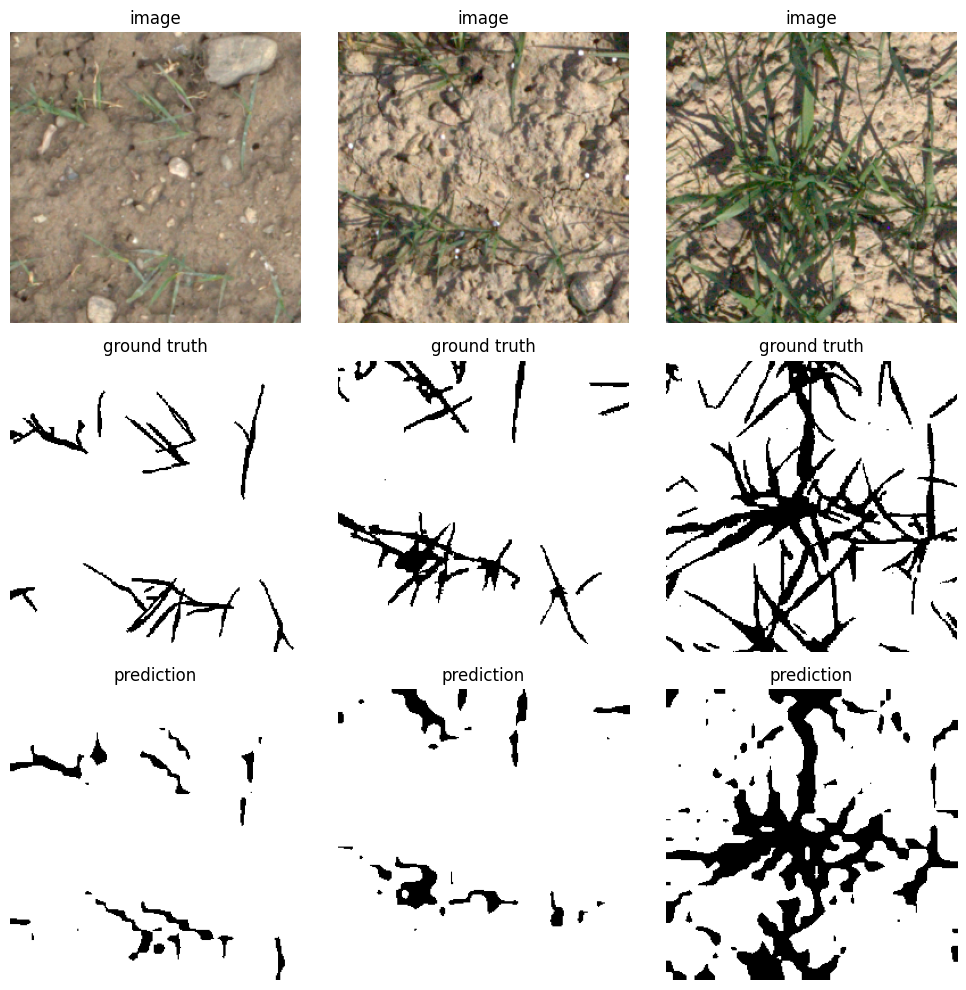

In [133]:
images, masks = next(iter(testloader))
images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = net(images)["out"]
    probs = torch.sigmoid(outputs)
    preds = (probs > 0.5).float()

fig, ax = plt.subplots(3, 3, figsize=(10, 10))

for i in range(3):
    img = images[i].cpu().numpy().transpose(1, 2, 0)
    gt = masks[i, 0].cpu().numpy()
    pred = preds[i, 0].cpu().numpy()

    ax[0, i].imshow(img)
    ax[0, i].set_title("image")
    ax[0, i].axis("off")

    ax[1, i].imshow(gt, cmap="gray")
    ax[1, i].set_title("ground truth")
    ax[1, i].axis("off")

    ax[2, i].imshow(pred, cmap="gray")
    ax[2, i].set_title("prediction")
    ax[2, i].axis("off")

plt.tight_layout()
plt.show()


# save results

In [134]:
import os
from datetime import datetime
import pandas as pd

# settings
results_file = "training_results_history.xlsx"

# update per run
model_name = "DeepLabV3_ResNet50"
run_name = "fine_tune_run_8"
notes = "combined tversky loss @ alpha=0.6, beta=0.4"

# collect results
new_result = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "run_name": run_name,
    "model": model_name,
    "epoch": current_epoch,
    "loss": round(float(test_metrics["loss"]), 4),
    "precision": round(float(test_metrics["precision"]), 4),
    "recall": round(float(test_metrics["recall"]), 4),
    "f1": round(float(test_metrics["f1"]), 4),
    "iou": round(float(test_metrics["iou"]), 4),
    "notes": notes,
}

new_df = pd.DataFrame([new_result])

# append to existing excel file
if os.path.exists(results_file):
    old_df = pd.read_excel(results_file)
    updated_df = pd.concat([old_df, new_df], ignore_index=True)
else:
    updated_df = new_df

# save back to excel
updated_df.to_excel(results_file, index=False)

print(f"results saved to: {results_file}")
print()
print(updated_df.tail(10))

results saved to: training_results_history.xlsx

             timestamp         run_name               model  epoch    loss  \
0  2026-04-13 00:00:00  pre_fine_tuning  DeepLabV3_ResNet50     40  0.3044   
1  2026-04-13 17:31:22  fine_tune_run_1  DeepLabV3_ResNet50     50  0.2605   
2  2026-04-13 17:48:55  fine_tune_run_2  DeepLabV3_ResNet50     50  0.2584   
3  2026-04-13 18:04:16  fine_tune_run_3  DeepLabV3_ResNet50     50  0.2570   
4  2026-04-13 18:16:07  fine_tune_run_4  DeepLabV3_ResNet50     50  0.2527   
5  2026-04-13 18:47:43  fine_tune_run_5  DeepLabV3_ResNet50     50  0.3791   
6  2026-04-13 19:06:27  fine_tune_run_6  DeepLabV3_ResNet50     50  0.3750   
7  2026-04-13 19:18:18  fine_tune_run_6  DeepLabV3_ResNet50     50  0.3703   
8  2026-04-13 19:30:13  fine_tune_run_7  DeepLabV3_ResNet50     50  0.3721   
9  2026-04-13 19:41:48  fine_tune_run_8  DeepLabV3_ResNet50     50  0.3786   

   precision  recall      f1     iou  \
0     0.9270  0.8639  0.8937  0.8098   
1     0.9189